# Violent Hate Crime Classification in Chicago

This notebook analyzes hate crimes in Chicago (2012–2025) to identify factors associated with violent hate crimes.  

We implement two models:
- Logistic Regression (baseline)
- Random Forest (tuned)  

Key objectives:
1. Predict whether a hate crime is violent.
2. Identify which features drive violent hate crime.
3. Visualize feature importance and partial dependencies.

Data source: Chicago Police Department (open data).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import PartialDependenceDisplay

np.random.seed(42)

# Load the data
`crimes.csv` contains CPD hate crime records from 2012–2025.

In [ ]:
df = pd.read_csv("data/crimes.csv")

df.head()

Dataset shape: (1604, 14)


,Unnamed: 0,RD_NO,DATEOCC,IUCR_CODE,Offense,CLASS,Motivations,CPD.Area,DISTRICT,Community,WARD,DISPOSITION,X,violent_crime
0,1,HV113109,1/10/2012 12:00:00 AM,1320,CRIMINAL DAMAGE: TO VEHICLE,B - RELIGION,ANTI-JEWISH,Central,12.0,WEST TOWN,32,UNDETERMINED,NaN,0
1,2,HV117394,1/12/2012 12:00:00 AM,580,STALKING: SIMPLE,B - RELIGION,ANTI-MULTIPLE RELIGIONS/GROUPS,Central,18.0,NEAR NORTH SIDE,32,UNFOUNDED,NaN,0
2,3,HV119102,1/16/2012 12:00:00 AM,320,ROBBERY: STRONGARM - NO WEAPON,A - RACE/ETHNICITY/ANCESTRY,ANTI-ASIAN,Central,9.0,ARMOUR SQUARE,11,UNFOUNDED,NaN,1
3,4,HV132973,1/26/2012 12:00:00 AM,1305,CRIMINAL DAMAGE: CRIMINAL DEFACEMENT,C - SEXUAL ORIENTATION,ANTI-GAY (MALE),Central,18.0,LINCOLN PARK,43,UNDETERMINED,NaN,0
4,5,HV139773,1/31/2012 12:00:00 AM,2825,OTHER OFFENSE: HARASSMENT BY TELEPHONE,A - RACE/ETHNICITY/ANCESTRY,ANTI-BLACK/AFRICAN-AMERICAN,Central,1.0,NEAR SOUTH SIDE,2,UNFOUNDED,NaN,0


# Feature Engineering

- Convert `DATEOCC` to season (Winter, Spring, Summer, Fall)
- Encode categorical variables using `pd.get_dummies`
- Define target variable `violent_crime` (1 = violent, 0 = non-violent)
- Prepare `X` (features) and `y` (target)

In [3]:
df["DATEOCC"] = pd.to_datetime(df["DATEOCC"])

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["DATEOCC"].dt.month.apply(get_season)

/var/folders/q7/94r5v2sj05sd2y2354d89zym0000gn/T/ipykernel_48617/1090974346.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATEOCC"] = pd.to_datetime(df["DATEOCC"])


In [4]:
features = ["Motivations", "CPD.Area", "DISPOSITION", "season"]
target = "violent_crime"

X = df[features]
y = df[target]

In [ ]:
X = pd.get_dummies(X, columns=features, drop_first=False)

Encoded feature matrix shape: (1604, 44)


# Modeling
- Train a baseline Logistic Regression model
- Evaluate accuracy and ROC-AUC

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42, stratify=y)

In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

log_reg.fit(X_train, y_train)

y_log_pred = log_reg.predict(X_test)
y_log_prob = log_reg.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test, y_log_pred)
log_auc = roc_auc_score(y_test, y_log_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy: {log_accuracy:.3f}")
print(f"ROC-AUC: {log_auc:.3f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_log_pred))

Logistic Regression Performance
--------------------------------
Accuracy: 0.688
ROC-AUC: 0.759

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.71      0.68       188
           1       0.72      0.67      0.70       213

    accuracy                           0.69       401
   macro avg       0.69      0.69      0.69       401
weighted avg       0.69      0.69      0.69       401



- Train a Random Forest classifier
- Perform hyperparameter tuning (`n_estimators`, `max_features`, `min_samples_leaf`)
- Evaluate accuracy and ROC-AUC

In [19]:
rf_params = {"n_estimators": [100, 200, 300], "max_features": [4, 6, 8], "min_samples_leaf": [1, 2, 4]}

rf = RandomForestClassifier(random_state=42, class_weight="balanced")

rf_tuned = GridSearchCV(rf, rf_params, scoring="roc_auc", cv=5, n_jobs=-1)

rf_tuned.fit(X_train, y_train)

print("Best RF Parameters:", rf_tuned.best_params_)

Best RF Parameters: {'max_features': 6, 'min_samples_leaf': 4, 'n_estimators': 200}


In [ ]:
y_rf_pred = rf_tuned.predict(X_test)
y_rf_prob = rf_tuned.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_auc = roc_auc_score(y_test, y_rf_prob)

print("Random Forest Performance")
print("--------------------------")
print(f"Accuracy: {rf_accuracy:.3f}")
print(f"ROC-AUC: {rf_auc:.3f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_rf_pred))

Random Forest Performance
--------------------------
Accuracy: 0.688
ROC-AUC: 0.749

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.68      0.67       188
           1       0.71      0.70      0.70       213

    accuracy                           0.69       401
   macro avg       0.69      0.69      0.69       401
weighted avg       0.69      0.69      0.69       401



- Compare Logitistic Regression and Tuned Random Forest using Accuracy, ROC-AUC, and Confusion Matrix

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "ROC-AUC": [log_auc, rf_auc]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.668329,0.749091
1,Random Forest,0.675810,0.739582


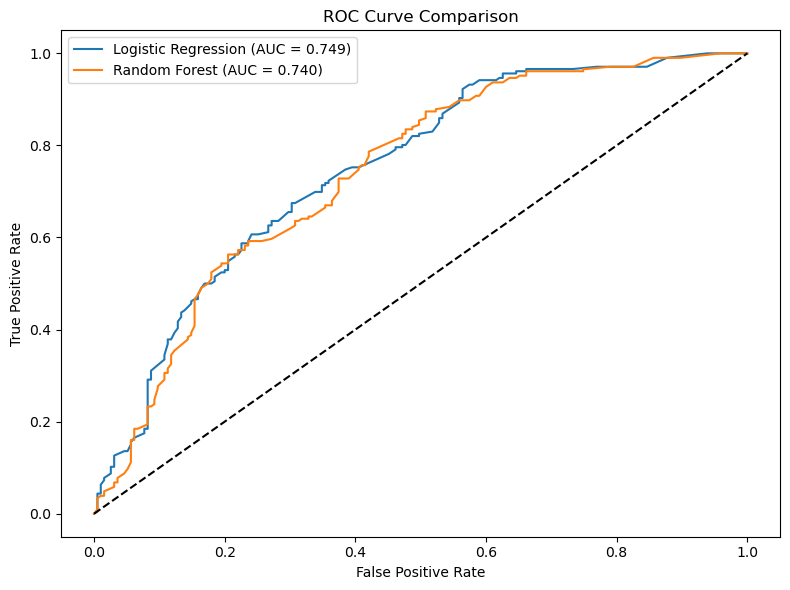

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_rf_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png")
plt.show()

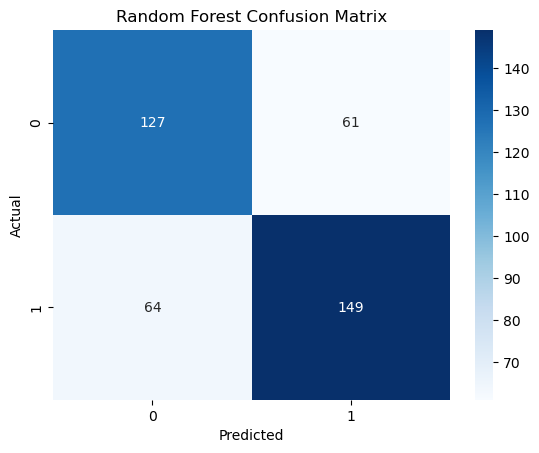

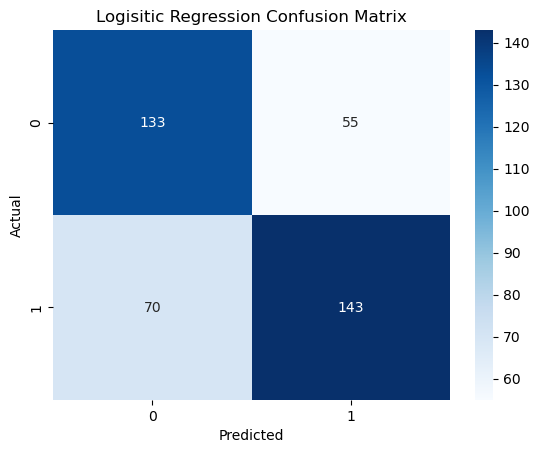

In [24]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_rf_pred, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_log_pred, "Logisitic Regression Confusion Matrix")

The Logisitic Regression model has a higher ROC-AUC, but the Tuned Random Forest has a slightly higher accuracy. These two models exhibit roughly similar predictive capabilities.

# Results
- Feature importances for Tuned Random Forest
- Partial Dependency plots for top features

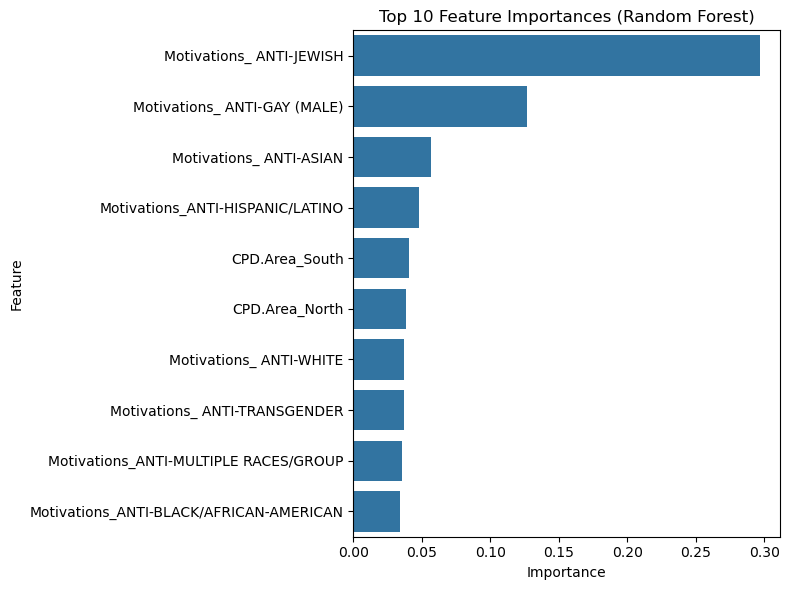

,Feature,Importance
12,Motivations_ ANTI-JEWISH,0.296702
7,Motivations_ ANTI-GAY (MALE),0.126910
2,Motivations_ ANTI-ASIAN,0.056665
26,Motivations_ANTI-HISPANIC/LATINO,0.048136
34,CPD.Area_South,0.040975
33,CPD.Area_North,0.038550
22,Motivations_ ANTI-WHITE,0.037096
20,Motivations_ ANTI-TRANSGENDER,0.036719
28,Motivations_ANTI-MULTIPLE RACES/GROUP,0.035581
25,Motivations_ANTI-BLACK/AFRICAN-AMERICAN,0.034243


In [ ]:
best_rf = rf_tuned.best_estimator_

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = importances.head(10)

plt.figure(figsize=(8,6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png")
plt.show()

top_features

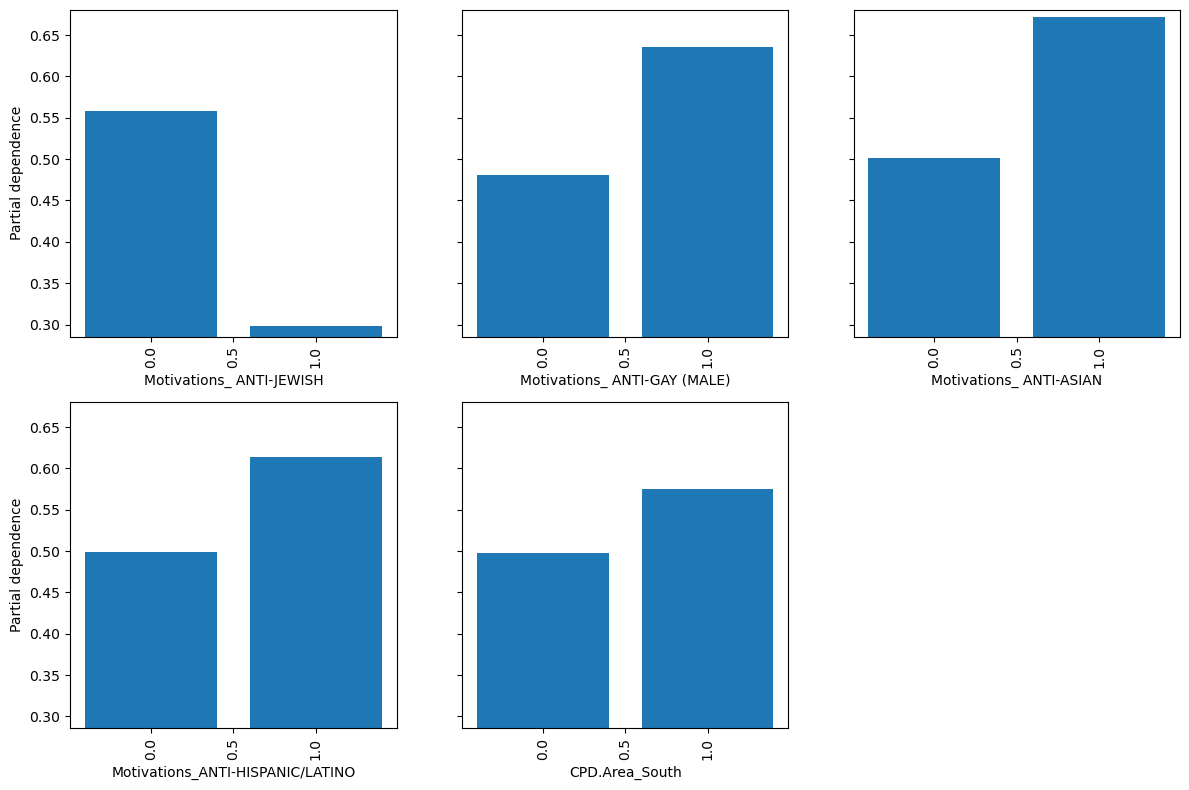

In [ ]:
top_feature_names = top_features["Feature"].head(5).tolist()

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=top_feature_names,
    categorical_features=top_feature_names,
    ax=ax
)

plt.tight_layout()
plt.savefig("outputs/partial_dependencies_1.png")
plt.show()

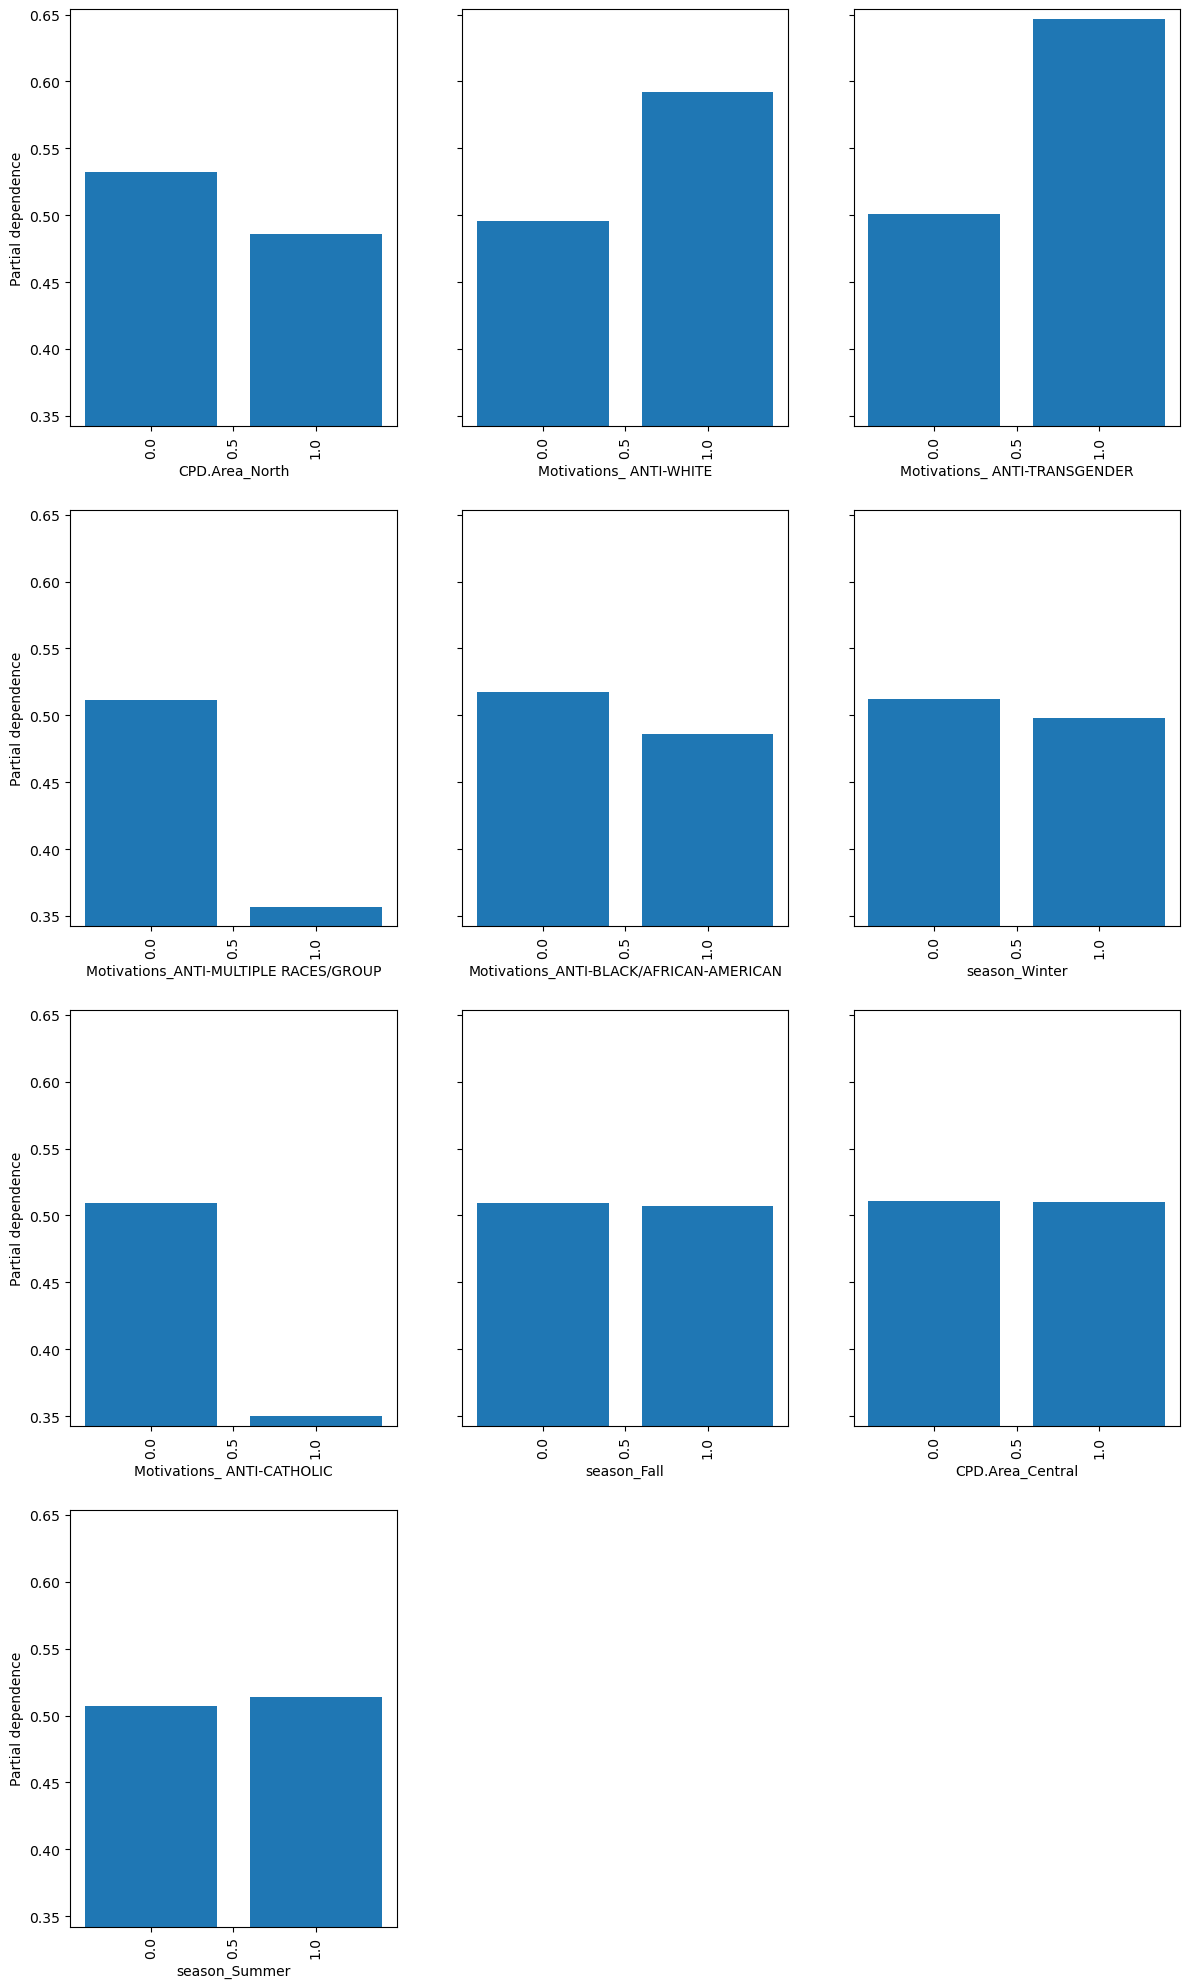

In [ ]:
top_15 = importances["Feature"].iloc[5:15].tolist()

fig, ax = plt.subplots(figsize=(12, 20))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=top_15,
    categorical_features=top_15,
    ax=ax
)

plt.tight_layout()
plt.savefig("outputs/partial_dependencies_2.png")
plt.show()

Partial dependence plots show how the top features affect the probability of violent crime:
- Anti-Jewish bias decreases likelihood of violence.
- Anti-Gay, Anti-Asian, and Anti-Hispanic biases increase likelihood.
- Southern CPD area increases likelihood of violence; North CPD area decreases likelihood
- Summer slightly increases likelihood; Winter slightly decreases likelihood